In [1]:
import yaml

base_dataset_path = "/kaggle/input/datasets/khoile1012/roundabount-spliting/yolo_split/"
yaml_path = f"{base_dataset_path}/dataset.yml"

with open(yaml_path, 'r', encoding='utf-8') as f:
    data = yaml.safe_load(f)

data["path"] = base_dataset_path

data["train"] = "train/images"
data["val"] = "val/images"
if "test" in data:
    data["test"] = "test/images"

new_yaml = "/kaggle/working/dataset.yml"
with open(new_yaml, "w", encoding='utf-8') as f:
    yaml.safe_dump(data, f, sort_keys=False, allow_unicode=True)

print("Saved new yaml:", new_yaml)

Saved new yaml: /kaggle/working/dataset.yml


In [2]:
pip install ultralytics 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.5 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [5]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [6]:
!wget https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n.pt

--2026-04-25 06:10:55--  https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n.pt
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/521807533/34b70ade-b6eb-4179-a60f-d6494307226b?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-25T06%3A58%3A18Z&rscd=attachment%3B+filename%3Dyolo11n.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-25T05%3A57%3A26Z&ske=2026-04-25T06%3A58%3A18Z&sks=b&skv=2018-11-09&sig=HOPwR22zZD8QDKIPX6NsJfPxI4K575eYbSgiheH9cq8%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NzA5Nzc1NiwibmJmIjoxNzc3MDk3NDU2LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmUud

# Cách hoạt động của mô hình YOLO 
![YOLO](https://images.viblo.asia/full/963815a3-930b-4f0b-9897-55fd9215458c.PNG)


## 1. Xương sống (Backbone)
- **Nhiệm vụ**: Trích xuất đặc trưng. Khi một bức ảnh đầu vào được đưa qua mạng, Backbone (thường là các mạng CNN) sẽ quét qua hình ảnh để trích xuất các đặc trưng quan trọng ở nhiều cấp độ, từ các góc cạnh cơ bản đến các hình dạng phức tạp.
## 2. Cổ (Neck)
- **Nhiệm vụ**: Tổng hợp đặc trưng. Neck làm nhiệm vụ thu thập và kết hợp các bản đồ đặc trưng (feature maps) từ nhiều tầng khác nhau của Backbone. Việc này giúp mô hình nhận diện tốt hơn các đối tượng ở nhiều kích thước khác nhau trước khi đưa ra dự đoán. (Lưu ý: Ở các phiên bản YOLO đời đầu như YOLOv1, phần Neck chưa được định hình rõ ràng và phức tạp như các phiên bản hiện đại).
## 3. Đầu (Head) - Đầu dự đoán
- Là nơi tiếp nhận đặc trưng và thực hiện việc dự đoán bounding box cùng phân loại đối tượng. Đầu ra của mô hình là một ma trận 3 chiều (tensor) có kích thước:
  $$S \times S \times (5 \times N + M)$$
- Ma trận ảnh được chia thành một lưới gồm $S \times S$ ô (grid cells).Mỗi ô vuông sẽ chịu trách nhiệm dự đoán $N$ Bounding Boxes và $M$ Classes (số lượng nhãn lớp đối tượng).Do đó, số lượng tham số mà mỗi ô cần dự đoán là $(5 \times N + M)$.Ví dụ minh họa:Giả sử hình ảnh được chia thành lưới $7 \times 7$ ô ($S=7$). Mỗi ô cần dự đoán $N=2$ bounding boxes và $M=3$ lớp đối tượng (ví dụ: con chó, ô tô, xe đạp).Kích thước ma trận đầu ra sẽ là: $7 \times 7 \times 13$.Khả năng dự đoán của toàn mạng là: $7 \times 7 \times 2 = 98$ bounding boxes.Giải phẫu con số $(5 \times N + M)$ trong mỗi ô lưới (với 13 tham số):Mỗi bounding box được đặc trưng bởi 5 thành phần: $(x, y, w, h, \text{prediction})$. Trong đó:$(x, y)$: Tọa độ tâm của bounding box (tương đối so với ô hiện tại).$(w, h)$: Chiều rộng và chiều cao của bounding box.$\text{prediction}$: Độ tin cậy (Confidence Score), được tính bằng $\Pr(\text{Object}) \times \text{IOU}_{\text{pred}}^{\text{truth}}$.Sắp xếp 13 tham số của ô cụ thể như sau:Tham số 1 đến 5 (Box 1): Lần lượt là $\Pr(\text{Object})$ (xác suất ô có chứa đối tượng), và các tọa độ, kích thước $x, y, w, h$.Tham số 6 đến 10 (Box 2): Tương tự như Box 1, dành cho bounding box thứ hai.Tham số 11 đến 13 (Xác suất có điều kiện): Lần lượt là xác suất ô đó chứa đối tượng cụ thể nào nếu đã có đối tượng xuất hiện: $\Pr(\text{chó} | \text{Object})$, $\Pr(\text{ô tô} | \text{Object})$, $\Pr(\text{xe đạp} | \text{Object})$.
- Nguồn: https://viblo.asia/p/tim-hieu-ve-yolo-trong-bai-toan-real-time-object-detection-yMnKMdvr57P

# 1. Các phiên bản của YOLOv11 (Object Detection)

YOLOv11 cung cấp nhiều kích cỡ mô hình để cân bằng giữa **tốc độ (FPS)** và **độ chính xác (mAP)**. Việc chọn đúng model rất quan trọng, đặc biệt với:
- Object nhỏ
- Mật độ dày (ví dụ: giao thông từ ảnh flycam)
## Bảng so sánh các phiên bản

| Phiên bản | Tên gọi | Đặc điểm | Ứng dụng |
|----------|--------|---------|----------|
| YOLO11n | Nano | Nhẹ nhất, nhanh nhất, độ chính xác thấp | Edge device (Raspberry Pi, Jetson Nano), real-time |
| YOLO11s | Small | Nhẹ, cân bằng tốt hơn Nano | Mobile, camera giám sát |
| YOLO11m | Medium | Cân bằng tốt giữa tốc độ & accuracy | Baseline cho đa số bài toán |
| YOLO11l | Large | Chính xác cao, model lớn | Detect object nhỏ, bị che |
| YOLO11x | Extra Large | Nặng nhất, chính xác nhất | Research, thi AI, server mạnh |

---

# 2. Arguments (Tham số) cốt lõi
## 2.1. Tham số Huấn luyện (Training)
- `data`: file `.yaml` chứa thông tin dataset (đường dẫn thư mục train/val, số lượng class, tên class).
- `epochs`: số vòng train (100–300)  
- `batch`: Kích thước batch (ví dụ: 16, 32, 64). Nếu bị lỗi Out of Memory (OOM), giảm chỉ số này xuống hoặc đặt batch=-1 để mô hình tự động tìm kích thước tối ưu (AutoBatch).
- `imgsz`: Kích thước ảnh đầu vào là 640
- `device`: GPU (`0`) hoặc `cpu`  
- `optimizer`:  Thuật toán tối ưu hóa (SGD, Adam, AdamW). AdamW thường hoạt động rất tốt trên các bài toán phức tạp.
## 2.2. Data Augmentation 
Giúp mô hình hiảm overfitting và tăng khả năng tổng quát hóa  
### Các tham số chính:
- `mosaic`: Tính năng gộp 4 ảnh thành 1. Mặc định là 1.0 (100% sử dụng). Rất tốt để giúp mô hình làm quen với các khung hình có mật độ đối tượng dày đặc.
- `mixup`: Trộn 2 ảnh đè lên nhau. Tăng độ phức tạp cho dữ liệu.
- `degrees`: Xoay ảnh một góc ngẫu nhiên (ví dụ: 0.0 đến 180.0). Rất quan trọng khi đối tượng có thể xuất hiện ở bất kỳ góc độ nào.
- `scale`:  Phóng to hoặc thu nhỏ ảnh ngẫu nhiên.
## 2.3. Suy luận & Đánh giá (Inference / Validation)
- `conf`: Ngưỡng tin cậy (Confidence Threshold). Mặc định là 0.25. Bất kỳ bounding box nào có xác suất dự đoán dưới mức này sẽ bị loại bỏ.
- `iou`: Ngưỡng Intersection Over Union cho thuật toán Non-Maximum Suppression (NMS). Mặc định là 0.7. Dùng để triệt tiêu các bounding box trùng lặp cùng trỏ vào một đối tượng.
- `save`: lưu ảnh/video kết quả  

**Nguồn**: 
- https://docs.ultralytics.com/models/yolo11/
- https://docs.ultralytics.com/guides/yolo-data-augmentation/#flip-left-right-fliplr
- https://blog.roboflow.com/yolov11-how-to-train-custom-data/

### Lựa chọn độ phân giải ảnh (Image Size = 640)

Độ phân giải đầu vào được chọn là 640x640. Là giá trị mặc định và phổ biến trong YOLO, giúp cân bằng giữa 
độ chính xác và tốc độ xử lý.

Với độ phân giải này, mô hình vẫn giữ được đủ chi tiết để phát hiện  các đối tượng nhỏ như phương tiện trong ảnh, đồng thời đảm bảo 
thời gian suy luận không quá cao khi chạy trên CPU.

Nếu sử dụng độ phân giải thấp hơn, mô hình có thể bỏ sót các đối tượng nhỏ. Ngược lại, nếu sử dụng độ phân giải cao hơn, thời gian xử lý sẽ tăng đáng kể  mà không cải thiện nhiều về hiệu năng.


# 3. Training Model YOLO và so sánh hiệu suất của các model

## 3.1 Traning 
### 3.1.1 Model YOLOv11n

In [7]:
model_v11n = YOLO("yolo11n.pt") 

model_v11n.train(
    data=new_yaml,
    epochs=100,
    imgsz=640,
    batch=16,
    project = "/kaggle/working",
    name= "training_backup_YOLOv11n",
    device = 0,
    # augmentation 
    degrees=15,
    translate=0.1,
    scale=0.5,
    mosaic=1.0,
    fliplr=0.0,
    optimizer="AdamW",
    lr0=0.001
)

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=training_backup_YOLOv11n, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=Tru

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79f85f5edc70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [9]:
# metrics_v11n = model_v11n.val(data=new_yaml)
# print(metrics_v11n.box.map50)

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1355.4±156.7 MB/s, size: 880.0 KB)
val: Scanning /kaggle/input/datasets/khoile1012/roundabount-spliting/yolo_split/val/labels... 195 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 195/195 687.4it/s 0.3s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/khoile1012/roundabount-spliting/yolo_split/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.6it/s 3.6s0.1s
                   all        195       3151      0.814      0.801      0.844      0.603
                   car        184       3034      0.984      0.997      0.994      0.795
                 cycle         33         65       0.77      0.773      0.775      0.396
                   bus         17     

###  3.1.2. Model YOLOv11s

In [8]:
model_v11s = YOLO("yolo11s.pt") 

model_v11s.train(
    data=new_yaml,
    epochs=100,
    imgsz=640,
    batch=16,
    project = "/kaggle/working",
    name= "training_backup_YOLOv11s",
    device = 0,
    # augmentation 
    degrees=15,
    translate=0.1,
    scale=0.5,
    mosaic=1.0,
    fliplr=0.0,
    optimizer="AdamW",
    lr0=0.001
)

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=training_backup_YOLOv11s, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=Tru

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79f94faa96a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [9]:
# metrics_v11s = model_v11s.val(data=new_yaml)
# print(metrics_v11s.box.map50)

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1069.5±285.5 MB/s, size: 867.3 KB)
val: Scanning /kaggle/input/datasets/khoile1012/roundabound-dataset/yolo_split/val/labels... 196 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 196/196 681.2it/s 0.3s0.2s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/khoile1012/roundabound-dataset/yolo_split/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.5it/s 3.7s0.2s
                   all        196       3160      0.903      0.868      0.899      0.694
                   car        186       3037      0.992      0.998      0.995      0.836
                 cycle         33         68      0.983      0.852      0.873      0.551
                   bus         18      

### 3.1.3 Model YOLOv11m

In [9]:
model_v11m = YOLO("yolo11m.pt") 

model_v11m.train(
    data=new_yaml,
    epochs=100,
    imgsz=640,
    batch=16,
    project = "/kaggle/working",
    name= "training_backup_YOLOv11m",
    device = 0,
    # augmentation 
    degrees=15,
    translate=0.1,
    scale=0.5,
    mosaic=1.0,
    fliplr=0.0,
    optimizer="AdamW",
    lr0=0.001
)

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=training_backup_YOLOv11m, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=Tru

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79f94f8d0e60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [11]:
# metrics_v11m = model_v11m.val(data=new_yaml)
# print(metrics_v11m.box.map50)

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,033,887 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 936.0±477.2 MB/s, size: 867.3 KB)
val: Scanning /kaggle/input/datasets/khoile1012/roundabound-dataset/yolo_split/val/labels... 196 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 196/196 547.4it/s 0.4s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/khoile1012/roundabound-dataset/yolo_split/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.4it/s 5.3s0.3s
                   all        196       3160      0.902      0.857      0.894      0.683
                   car        186       3037      0.997      0.993      0.995       0.83
                 cycle         33         68      0.996      0.779      0.865      0.561
                   bus         18      

## Kết quả của 3 mô hình

In [10]:
metrics_v11n = model_v11n.val(data=new_yaml)
print(metrics_v11n.box.map50)

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 545.8±205.9 MB/s, size: 877.1 KB)
val: Scanning /kaggle/input/datasets/khoile1012/roundabount-spliting/yolo_split/val/labels... 195 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 195/195 436.4it/s 0.4s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/khoile1012/roundabount-spliting/yolo_split/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.9it/s 3.3s0.1s
                   all        195       3151      0.814      0.801      0.844      0.603
                   car        184       3034      0.984      0.997      0.994      0.795
                 cycle         33         65       0.77      0.773      0.775      0.396
                   bus         17      

In [11]:
metrics_v11s = model_v11s.val(data=new_yaml)
print(metrics_v11s.box.map50)

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 714.4±37.2 MB/s, size: 943.1 KB)
val: Scanning /kaggle/input/datasets/khoile1012/roundabount-spliting/yolo_split/val/labels... 195 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 195/195 671.2it/s 0.3s0.2s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/khoile1012/roundabount-spliting/yolo_split/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.4it/s 3.8s0.2s
                   all        195       3151      0.897      0.857       0.89      0.691
                   car        184       3034      0.994      0.995      0.995      0.825
                 cycle         33         65      0.939      0.754      0.816      0.484
                   bus         17      

In [12]:
metrics_v11m = model_v11m.val(data=new_yaml)
print(metrics_v11m.box.map50)

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,033,887 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 587.2±130.6 MB/s, size: 834.0 KB)
val: Scanning /kaggle/input/datasets/khoile1012/roundabount-spliting/yolo_split/val/labels... 195 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 195/195 734.1it/s 0.3s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/khoile1012/roundabount-spliting/yolo_split/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.6it/s 5.1s0.3s
                   all        195       3151      0.941      0.887      0.939       0.74
                   car        184       3034      0.996      0.992      0.995      0.829
                 cycle         33         65          1      0.786       0.88      0.589
                   bus         17    

## 3.2. So sánh 

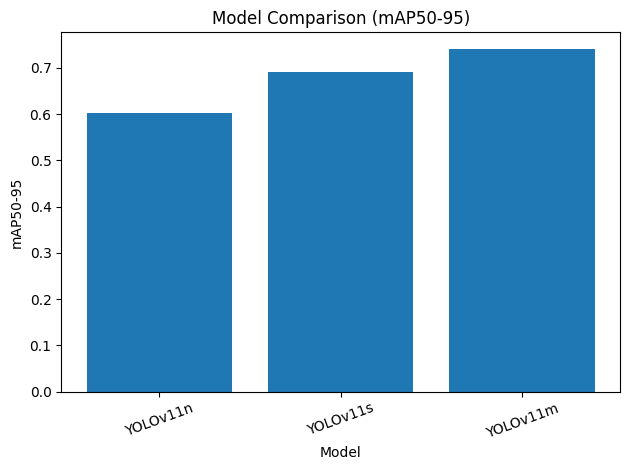

In [13]:
import matplotlib.pyplot as plt
import numpy as np
models = ["YOLOv11n", "YOLOv11s" ,"YOLOv11m"]

# mAP50-95
map5095 = [0.603, 0.691,0.74]
# Chart so sánh mAP 50-95 của từng mô hình 
plt.figure()
plt.bar(models, map5095)
plt.title("Model Comparison (mAP50-95)")
plt.xlabel("Model")
plt.ylabel("mAP50-95")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


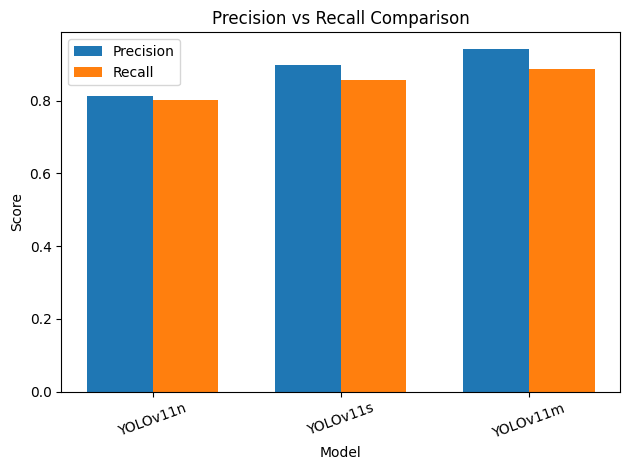

In [14]:
models = ["YOLOv11n", "YOLOv11s" ,"YOLOv11m"]
# Precision & Recall
precision = [0.814, 0.897 , 0.941]
recall = [0.801, 0.857,0.887]
x = np.arange(len(models))
width = 0.35

# Chart so sánh chỉ số Precision vs Recall 
plt.figure()
plt.bar(x - width/2, precision, width, label="Precision")
plt.bar(x + width/2, recall, width, label="Recall")

plt.xticks(x, models, rotation=20)
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Precision vs Recall Comparison")
plt.legend()
plt.tight_layout()
plt.show()

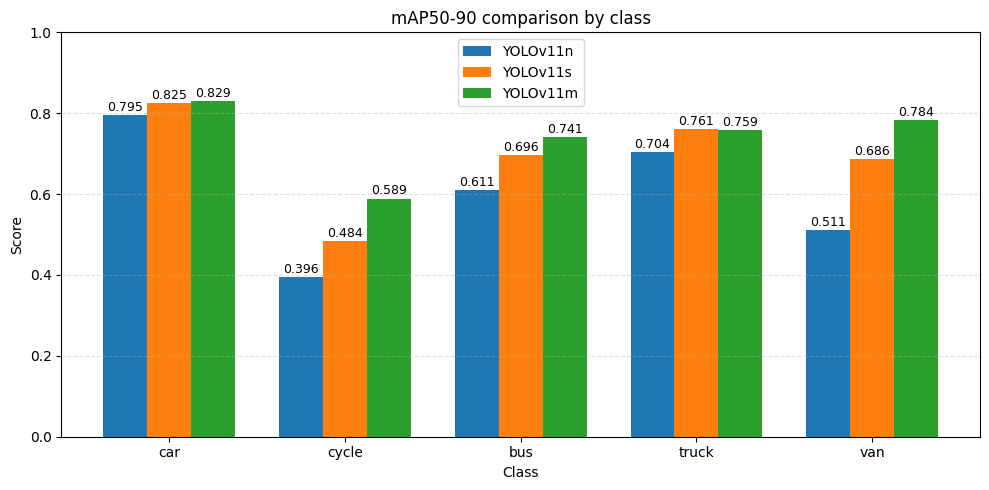

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data
classes = ['car', 'cycle', 'bus', 'truck', 'van']
yolo_n = [0.795, 0.396, 0.611, 0.704, 0.511]
yolo_s = [0.825, 0.484, 0.696, 0.761, 0.686]
yolo_m = [0.829, 0.589, 0.741, 0.759, 0.784]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10, 5))

bars_n = plt.bar(x - width, yolo_n, width, label='YOLOv11n')
bars_s = plt.bar(x, yolo_s, width, label='YOLOv11s')
bars_m = plt.bar(x + width, yolo_m, width, label='YOLOv11m')

# Ghi số lên đầu mỗi cột
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                 f'{height:.3f}', ha='center', fontsize=9)

add_labels(bars_n)
add_labels(bars_s)
add_labels(bars_m)

plt.xticks(x, classes)
plt.xlabel("Class")
plt.ylabel('Score')
plt.title('mAP50-90 comparison by class')
plt.legend()

plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## So sánh hiệu năng các mô hình YOLOv11

### Bảng tổng hợp hiệu năng tổng thể 

| Model      | Precision | Recall | mAP50 | mAP50-95 |
|------------|-----------|--------|-------|----------|
| YOLOv11n   | 0.814     | 0.801  | 0.844 | 0.603    |
| YOLOv11s   | 0.897     | 0.857  | 0.890 | 0.691    |
| YOLOv11m   | **0.941** | **0.887** | **0.939** | **0.740** |

### So sánh chỉ số mAP50-95 theo từng nhãn (Class)

| Class  | Instances | YOLOv11n | YOLOv11s | YOLOv11m |
|--------|-----------|----------|----------|----------|
| car    | 3034      | 0.795    | 0.825    | **0.829**|
| cycle  | 65        | 0.396    | 0.484    | **0.589**|
| bus    | 21        | 0.611    | 0.696    | **0.741**|
| truck  | 23        | 0.704    | **0.761**| 0.759    |
| van    | 8         | 0.511    | 0.686    | **0.784**|

---

### Nhận xét & Phân tích 

Dựa vào số liệu thực nghiệm trên tập Validation, rút ra các đặc điểm sau của từng phiên bản YOLOv11:

1. **Nhóm phương tiện chiếm phần lớn (`car`):** Đặc trưng của ô tô rất dễ nhận diện và số lượng dữ liệu đã bão hòa (hơn 3000 instances). Do đó, cả 3 mô hình đều đạt mức mAP50 tiệm cận sự hoàn hảo (~0.995). Việc tăng kích thước mô hình không mang lại lợi ích đáng kể cho lớp này.
2. **Sự vượt trội của các mô hình lớn:**
   Về mặt tổng thể, `YOLOv11m` cho ra các thông số ấn tượng nhất, đặc biệt là kéo Recall của các lớp khó lên mức cao. Bản `YOLOv11n` bộc lộ rõ điểm yếu khi đối mặt với các lớp thiểu số (Recall của `van` chỉ đạt 0.500, bỏ sót 50% phương tiện).

#### Phát hiện điểm bất thường (Data Anomaly / Overfitting)
Dù `YOLOv11m` có điểm số cao nhất, nhưng khi đi sâu vào chi tiết, mô hình này đang bộc lộ những dấu hiệu **học vẹt (Overfitting)** nghiêm trọng vào bối cảnh:
* **Sự hoàn hảo vô lý ở lớp siêu hiếm:** Lớp `van` và `bus` có số lượng cực kỳ ít (lần lượt chỉ có 8 và 21 Bounding Box trong toàn bộ tập Val). Tuy nhiên, `YOLOv11m` lại đạt mAP50 cho `van` lên tới 0.897 và `bus` là 0.975. Khả năng rất cao mô hình không thực sự học được "đặc trưng của xe van/bus", mà chỉ đang học thuộc lòng hình dáng của 1-2 chiếc xe cụ thể chạy ngang qua camera cố định trong các frame ảnh liên tiếp.
* **Mất cân bằng Precision-Recall ở lớp `cycle`:** Mô hình `v11m` đạt Precision tuyệt đối 1.0 (không bao giờ bắt sai) nhưng Recall chỉ 0.786. Điều này cho thấy mô hình đang bị Over-confidence, chỉ dám dự đoán khi đối tượng quá rõ ràng và bỏ qua các trường hợp hơi mờ hoặc bị che khuất.

---

### Kết luận: Lựa chọn mô hình cho quá trình Hyperparameter Tuning (Optuna)

**Quyết định: Chọn `YOLOv11s` làm mô hình cốt lõi để tiến hành tối ưu hóa siêu tham số (Hyperparameter Tuning).**

**Lý do lựa chọn:**
1. **Điểm "ngọt" của kiến trúc (Sweet Spot):** Bản `v11n` quá yếu để trích xuất đặc trưng của xe tải/van, trong khi bản `v11m` quá lớn dẫn đến hiện tượng học vẹt (overfit) ngay lập tức vào tập dữ liệu mất cân bằng. `YOLOv11s` cung cấp một nền tảng vững chắc (mAP50 đạt 89.0%) với chi phí tính toán hợp lý.
2. **Dư địa để tối ưu (Room for Improvement):** Các chỉ số của `YOLOv11s` trên lớp `cycle` (Recall: 0.754) và `van` (Recall: 0.625) cho thấy mô hình này chưa bị "chín ép". Áp dụng Optuna để tìm kiếm các tham số Data Augmentation (như MixUp, HSV, Copy-Paste) sẽ ép `YOLOv11s` tập trung học được các phương tiện này một cách tổng quát hóa mà không bị rơi vào bẫy học thuộc lòng như bản `v11m`.

#  4. Hyperpagrameter tunning cho mô hình đạt hiệu suất cao nhất

In [16]:
import optuna
# Tối ưu hyperparameter
def objective(trial):
    """Hàm mục tiêu cho Optuna tìm kiếm siêu tham số tốt nhất"""
    
    # 1. Khai báo không gian tìm kiếm các tham số cần tối ưu
    lr0 = trial.suggest_float('lr0', 1e-4, 1e-2, log=True)
    optimizer = trial.suggest_categorical('optimizer', ['SGD', 'AdamW'])
    momentum = trial.suggest_float('momentum', 0.7, 0.99)
    
    # 2.Thiết lập các tham số Augmentation dựa trên heatmap
    scale = trial.suggest_float('scale', 0.1, 0.9)
    mosaic = trial.suggest_float('mosaic', 0.0, 1.0)
    degrees = trial.suggest_float('degrees', 0.0, 90.0) # Xoay đa hướng
    fliplr = trial.suggest_float('fliplr', 0.0, 0.5)    # Lật ngang
    flipud = trial.suggest_float('flipud', 0.0, 0.5)    # Lật dọc
    
    model = YOLO("yolo11s.pt") 
    # 3. Huấn luyện thử nghiệm (Dùng số epochs nhỏ để tiết kiệm thời gian tune)
    results = model.train(
        data= new_yaml,
        epochs=15,             # 15 epochs cho mỗi trial
        imgsz=640,             # Sử dụng độ phân giải cao cho ảnh hàng không
        lr0=lr0,
        optimizer=optimizer,
        momentum=momentum,
        scale=scale,
        mosaic=mosaic,
        degrees=degrees,
        fliplr=fliplr,
        flipud=flipud,
        project = "/kaggle/working/tunning",
        name=f'trial_{trial.number}',
        verbose=False,
        plots=False
    )

    # 4. Trả về chỉ số mAP@50-95 để Optuna tối ưu hóa (Maximize)
    return results.box.map


In [17]:
# Tạo study tối ưu hóa theo hướng tăng dần (maximize)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
print("=====" * 50)
print("Đã tìm xong thông số tối ưu")
best_params = study.best_params
for key, value in best_params.items():
    print(f"  - {key}: {value}")


[I 2026-04-25 08:02:38,623] A new study created in memory with name: no-name-1e9a5762-de3b-48d2-b961-bbcee7ca7d1b


Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yml, degrees=2.8155484022028454, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.13008752363694237, flipud=0.18646639878572563, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0006559035401570327, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.8321391202124249, mosaic=0.7679298341624363, multi_scale=0.0, name=trial_0, nbs=64

[I 2026-04-25 08:06:18,414] Trial 0 finished with value: 0.6493784256661077 and parameters: {'lr0': 0.0006559035401570327, 'optimizer': 'AdamW', 'momentum': 0.8321391202124249, 'scale': 0.3399636615588264, 'mosaic': 0.7679298341624363, 'degrees': 2.8155484022028454, 'fliplr': 0.13008752363694237, 'flipud': 0.18646639878572563}. Best is trial 0 with value: 0.6493784256661077.


Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yml, degrees=19.116964098060617, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.4790177449264172, flipud=0.3191292648108072, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0015198848556920127, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.9806253101891061, mosaic=0.43392113889187967, multi_scale=0.0, name=trial_1, nbs=64,

[I 2026-04-25 08:10:03,406] Trial 1 finished with value: 0.36117852310843207 and parameters: {'lr0': 0.0015198848556920127, 'optimizer': 'AdamW', 'momentum': 0.9806253101891061, 'scale': 0.7422365056544212, 'mosaic': 0.43392113889187967, 'degrees': 19.116964098060617, 'fliplr': 0.4790177449264172, 'flipud': 0.3191292648108072}. Best is trial 0 with value: 0.6493784256661077.


...

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yml, degrees=7.86862743178141, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.19927914418145762, flipud=0.06828280954121574, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00011475411505382636, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.8170829477662821, mosaic=0.33048881389885165, multi_scale=0.0, name=trial_18, nbs=6

[I 2026-04-25 09:12:41,742] Trial 18 finished with value: 0.12480934653071142 and parameters: {'lr0': 0.00011475411505382636, 'optimizer': 'SGD', 'momentum': 0.8170829477662821, 'scale': 0.42325092810456116, 'mosaic': 0.33048881389885165, 'degrees': 7.86862743178141, 'fliplr': 0.19927914418145762, 'flipud': 0.06828280954121574}. Best is trial 0 with value: 0.6493784256661077.


Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yml, degrees=26.106395077068957, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.07504623083264716, flipud=0.36899715345639367, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001469198083360437, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.7724554709741898, mosaic=0.726222780561517, multi_scale=0.0, name=trial_19, nbs=64,

[I 2026-04-25 09:16:22,524] Trial 19 finished with value: 0.45626160774571345 and parameters: {'lr0': 0.001469198083360437, 'optimizer': 'AdamW', 'momentum': 0.7724554709741898, 'scale': 0.32335368578705204, 'mosaic': 0.726222780561517, 'degrees': 26.106395077068957, 'fliplr': 0.07504623083264716, 'flipud': 0.36899715345639367}. Best is trial 0 with value: 0.6493784256661077.


Đã tìm xong thông số tối ưu
  - lr0: 0.0006559035401570327
  - optimizer: AdamW
  - momentum: 0.8321391202124249
  - scale: 0.3399636615588264
  - mosaic: 0.7679298341624363
  - degrees: 2.8155484022028454
  - fliplr: 0.13008752363694237
  - flipud: 0.18646639878572563


# ÁP dụng best param vào mô hình YOLOv11s

In [18]:
# Khởi tạo lại mô hình YOLOv11s
final_model = YOLO('yolo11s.pt')
# Cập nhật các tham số augmentation 
best_params.update({
    'data': new_yaml,        
    'epochs': 100,
    'imgsz': 640,
    'batch': 16,
    'device': 0,
    'project': '/kaggle/working',
    'name': 'model_tuning',
    'patience': 20,
    'amp': True,
    'save': True
})

# Bắt đầu Train
final_results = final_model.train(**best_params)

print("Đã huấn luyện xong ")

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yml, degrees=2.8155484022028454, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.13008752363694237, flipud=0.18646639878572563, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0006559035401570327, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.8321391202124249, mosaic=0.7679298341624363, multi_scale=0.0, name=model_tuning, 

In [19]:
metrics_final = final_model.val(data=new_yaml)
print(metrics_final.box.map50)

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 585.6±150.7 MB/s, size: 877.1 KB)
val: Scanning /kaggle/input/datasets/khoile1012/roundabount-spliting/yolo_split/val/labels... 195 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 195/195 463.8it/s 0.4s0.2s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/khoile1012/roundabount-spliting/yolo_split/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.2it/s 4.0s0.2s
                   all        195       3151      0.885      0.867      0.925      0.727
                   car        184       3034      0.995      0.997      0.995      0.827
                 cycle         33         65      0.982       0.85       0.89      0.529
                   bus         17     

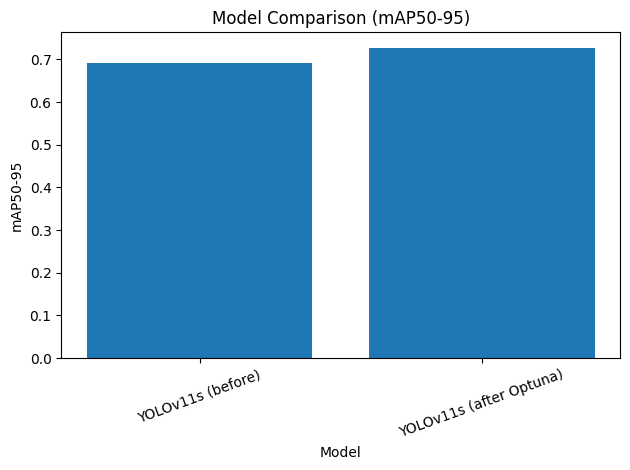

In [2]:
models = ["YOLOv11s (before)", "YOLOv11s (after Optuna)"]

# mAP50-95
map5095 = [0.691, 0.727]

# Precision & Recall
precision = [0.897, 0.885]
recall = [0.857,0.867]

plt.figure()
plt.bar(models, map5095)
plt.title("Model Comparison (mAP50-95)")
plt.xlabel("Model")
plt.ylabel("mAP50-95")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


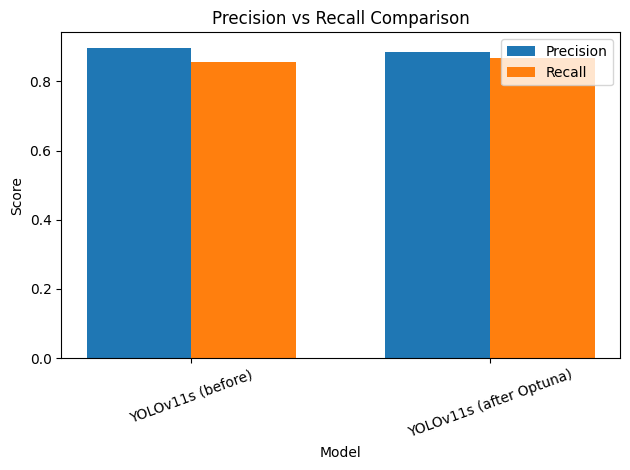

In [3]:
x = np.arange(len(models))
width = 0.35

# Chart so sánh chỉ số Precision vs Recall 
plt.figure()
plt.bar(x - width/2, precision, width, label="Precision")
plt.bar(x + width/2, recall, width, label="Recall")

plt.xticks(x, models, rotation=20)
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Precision vs Recall Comparison")
plt.legend()
plt.tight_layout()
plt.show()

## Kết quả mô hình YOLOv11s sau khi tối ưu bằng Optuna

### Tổng quan

| Metric        | Giá trị |
|--------------|--------|
| Precision    | 0.885  |
| Recall       | 0.867  |
| mAP50        | **0.925** |
| mAP50-95     | **0.727** |

### Hiệu năng theo từng lớp

| Class  | Precision | Recall | mAP50 | mAP50-95 |
|--------|----------|--------|-------|----------|
| car    | 0.995    | 0.997  | 0.995 | 0.827    |
| cycle  | 0.982    | 0.850  | 0.890 | 0.529    |
| bus    | 0.909    | 0.951  | 0.934 | 0.702    |
| truck  | 0.855    | 0.913  | 0.953 | 0.819    |
| van    | 0.682    | 0.625  | 0.852 | 0.756    |

### Nhận xét:
- Mô hình đạt hiệu năng tổng thể rất cao với **mAP50 = 0.925** và **mAP50-95 = 0.727**.
- Lớp **car** tiếp tục duy trì phong độ hoàn hảo (mAP50: 0.995).
- Đáng chú ý, lớp **cycle** đã đạt Precision cực cao (0.982) và mức Recall được kéo lên 0.850.
- Các phương tiện lớn/thiểu số như **truck** và **van** đều có mAP50 vượt mốc 0.85, chứng tỏ mô hình học đặc trưng rất tốt.

---

## So sánh YOLOv11s trước và sau khi tối ưu bằng Optuna

### Bảng tổng quan

| Metric        | Trước Optuna | Sau Optuna | Mức cải thiện |
|--------------|-------------|-----------|----------|
| Precision    | **0.897** | 0.885     | -0.012   |
| Recall       | 0.857       | **0.867** | +0.010   |
| mAP50        | 0.890       | **0.925** | +0.035   |
| mAP50-95     | 0.691       | **0.727** | +0.036   |

### So sánh chỉ số mAP50-95 theo từng lớp

| Class  | Trước Optuna | Sau Optuna | Mức cải thiện |
|--------|-------------|-----------|----------|
| car    | 0.825       | **0.827** | +0.002   |
| cycle  | 0.484       | **0.529** | +0.045   |
| bus    | 0.696       | **0.702** | +0.006   |
| truck  | 0.761       | **0.819** | +0.058   |
| van    | 0.686       | **0.756** | +0.070   |

### Nhận xét:

- **Sự thành công toàn diện:** Điểm sáng lớn nhất của đợt tối ưu này là **100% các lớp đều được cải thiện chỉ số mAP50-95**. Điều này chứng minh Optuna đã tìm ra bộ tham số giúp Bounding Box ôm sát vật thể hơn trên mọi phương tiện.
- **Giải cứu lớp thiểu số:** Các lớp khó nhằn nhất đều có bước nhảy vọt ấn tượng. Cụ thể, `van` tăng **+0.070**, `truck` tăng **+0.058**, và `cycle` tăng **+0.045**. Quá trình Tuning đã thực sự ép mô hình chú ý đến những phương tiện hiếm gặp này thay vì chỉ tập trung vào ô tô.
- **Sự đánh đổi hợp lý (Trade-off):** Mặc dù Precision tổng thể giảm nhẹ (-0.012), nhưng bù lại Recall tăng (+0.010) và điểm mAP tổng vọt lên mạnh mẽ. Việc này thể hiện mô hình đã giảm bớt sự Over-confidence, dám bắt nhiều đối tượng hơn và độ chính xác của các khung hình (IoU) cao hơn hẳn.

### Kết luận:
- Quá trình Hyperparameter Tuning bằng Optuna đã phát huy tác dụng xuất sắc, khắc phục triệt để tình trạng mất cân bằng giữa các lớp.
- Mô hình YOLOv11s hiện tại đạt được sự hài hòa tuyệt vời giữa độ chính xác, khả năng tổng quát hóa và tốc độ, hoàn toàn đủ điều kiện để chốt làm phiên bản cuối cùng mang đi Inference (kiểm thử thực tế) trên tập Test.

In [20]:
metrics_v11n_test = model_v11n.val(data=new_yaml,split = "test")
print(metrics_v11n_test.box.map50)

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 38.0±10.9 MB/s, size: 902.9 KB)
val: Scanning /kaggle/input/datasets/khoile1012/roundabount-spliting/yolo_split/test/labels... 98 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 98/98 98.3it/s 1.0s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/khoile1012/roundabount-spliting/yolo_split/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.3it/s 3.0s0.2ss
                   all         98       1596      0.969      0.907      0.968      0.726
                   car         93       1533      0.995      0.996      0.995       0.81
                 cycle         16         33          1      0.674      0.938      0.507
                   bus         10         13      0.975          1      0.995      0.759
                 truck         11     

In [21]:
metrics_v11s_test = model_v11s.val(data=new_yaml,split = "test")
print(metrics_v11s_test.box.map50)

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.3±0.6 ms, read: 551.8±89.6 MB/s, size: 857.6 KB)
val: Scanning /kaggle/input/datasets/khoile1012/roundabount-spliting/yolo_split/test/labels... 98 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 98/98 495.6it/s 0.2s0.4s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/khoile1012/roundabount-spliting/yolo_split/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.3it/s 3.0s0.3ss
                   all         98       1596      0.826      0.939      0.933      0.709
                   car         93       1533      0.995      0.999      0.995      0.834
                 cycle         16         33      0.932       0.97      0.955      0.647
                   bus         10         13      0.925       0.95       0.99      0.782
                 truck         11   

In [22]:
metrics_v11m_test = model_v11m.val(data=new_yaml,split = "test")
print(metrics_v11m_test.box.map50)

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.2±0.5 ms, read: 533.2±146.8 MB/s, size: 926.7 KB)
val: Scanning /kaggle/input/datasets/khoile1012/roundabount-spliting/yolo_split/test/labels... 98 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 98/98 528.8it/s 0.2s0.3s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/khoile1012/roundabount-spliting/yolo_split/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.1it/s 3.4s0.4ss
                   all         98       1596      0.918      0.926      0.966      0.763
                   car         93       1533      0.997      0.996      0.995       0.84
                 cycle         16         33          1      0.913      0.962      0.682
                   bus         10         13      0.922      0.923       0.97      0.784
                 truck         11  

In [23]:
metrics_final_test = final_model.val(data=new_yaml,split ="test")
print(metrics_final_test.box.map50)

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.2±0.5 ms, read: 542.7±53.3 MB/s, size: 855.9 KB)
val: Scanning /kaggle/input/datasets/khoile1012/roundabount-spliting/yolo_split/test/labels... 98 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 98/98 487.0it/s 0.2s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/khoile1012/roundabount-spliting/yolo_split/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.4it/s 3.0s0.2ss
                   all         98       1596      0.868      0.891       0.94      0.736
                   car         93       1533      0.998      0.988      0.995      0.834
                 cycle         16         33          1      0.657      0.965      0.626
                   bus         10         13          1      0.941      0.995      0.788
                 truck         11   

## Đánh giá và So sánh hiệu năng cuối cùng trên tập Test

### Bảng tổng quan hiệu năng của các mô hình

| Mô hình | Precision (P) | Recall (R) | mAP50 | mAP50-95 |
| :--- | :--- | :--- | :--- | :--- |
| YOLOv11n | **0.969** | 0.907 | **0.968** | 0.726 |
| YOLOv11s | 0.826 | **0.939** | 0.933 | 0.709 |
| YOLOv11m | 0.918 | 0.926 | 0.966 | **0.763** |
| YOLOv11s-optuna | 0.868 | 0.891 | 0.940 | 0.736 |

### So sánh chỉ số mAP50-95 chi tiết theo từng lớp

| Class | Instances | YOLOv11n | YOLOv11s | YOLOv11m | YOLOv11s-optuna |
| :--- | :--- | :--- | :--- | :--- | :--- |
| car | 1533 | 0.810 | 0.834 | **0.840** | 0.834 |
| cycle | 33 | 0.507 | 0.647 | **0.682** | 0.626 |
| bus | 13 | 0.759 | 0.782 | 0.784 | **0.788** |
| truck | 15 | 0.710 | 0.651 | 0.662 | **0.722** |
| van | 2 | **0.846** | 0.629 | **0.846** | 0.712 |

---

### Nhận xét & Phân tích trên tập Test

**1. Khẳng định giá trị của việc Tuning (v11s vs v11s-optuna):**
Kết quả trên tập Test độc lập đã chứng minh việc sử dụng Optuna là hoàn toàn đúng đắn. Mặc dù ở tập Test, Recall tổng thể của bản Optuna (0.891) có giảm nhẹ so với bản gốc (0.939), nhưng bù lại Precision tăng (+0.042) và đặc biệt là các chỉ số mAP đều tăng (mAP50-95 tăng từ 0.709 lên 0.736). Điều này cho thấy mô hình sau khi tuning đã **tổng quát hóa tốt hơn**, Bounding Box ôm sát vật thể hơn trên dữ liệu hoàn toàn mới.

**2. Sức mạnh của phiên bản lớn (YOLOv11m):**
Đúng với lý thuyết, khi được thử nghiệm trên tập Test, bản `YOLOv11m` thể hiện sức mạnh vượt trội về khả năng phát hiện chi tiết, dẫn đầu ở chỉ số quan trọng và khắt khe nhất là **mAP50-95 (0.763)**. Lớp `cycle` thường rất khó nhận diện vì kích thước nhỏ và hay bị che khuất, nhưng bản `m` đã kéo mAP50-95 lên tới 0.682, cao nhất trong cả 4 mô hình.

**3. Statistical Noise ở lớp Van & Bus:**
Cột Instances của tập Test, chỉ có vỏn vẹn **2 chiếc xe Van** và **13 chiếc xe Bus**. 
* Lớp `van` của `YOLOv11n` đạt mAP50-95 lên tới 0.846, ngang bằng với bản `m`. Tuy nhiên, với tập mẫu chỉ có 2 chiếc xe, con số này không mang nhiều ý nghĩa thống kê (có thể do 2 chiếc xe tải nhỏ này chạy qua ở góc máy quá đẹp và rõ nét). 
* Bản `v11s-optuna` gặp hiện tượng Precision của `van` sụt mạnh xuống 0.409 dù Recall = 1.0. Tức là nó đã nhận diện đúng 2 chiếc xe van đó, nhưng lại đi nhận thêm một số chiếc xe khác thành xe van.

### Kết luận chung
* **Nếu tài nguyên phần cứng cho phép (Server/GPU xịn):** `YOLOv11m` là sự lựa chọn tốt nhất với độ ổn định cao trên mọi phương tiện.
* **Nếu cần cân bằng giữa Tốc độ và Độ chính xác (Edge AI/Camera tích hợp):** `YOLOv11s-optuna` là nhà vô địch thực sự. Nó cho ra chất lượng Bounding Box bám sát vật thể rất tốt (thể hiện qua mAP50-95 vượt trội so với bản gốc) mà vẫn giữ được tốc độ FPS cao của dòng Small.

In [ ]:
# import shutil
# import os

# output_zip = '/kaggle/working/YOLOv11_training'

# items_to_zip = [
#     '/kaggle/working/yolo11m.pt',
#     '/kaggle/working/yolo11n.pt',
#     '/kaggle/working/yolo11s.pt',
#     '/kaggle/working/model_tuning',
#     '/kaggle/working/runs',
#     '/kaggle/working/training_backup_YOLOv11m',
#     '/kaggle/working/training_backup_YOLOv11n',
#     '/kaggle/working/training_backup_YOLOv11s'
# ]

# temp_dir = '/kaggle/working/temp_backup'

# #  XÓA TEMP CŨ TRƯỚC
# if os.path.exists(temp_dir):
#     shutil.rmtree(temp_dir)

# os.makedirs(temp_dir, exist_ok=True)

# # Copy file + folder
# for item in items_to_zip:
#     if os.path.exists(item):
#         dest = os.path.join(temp_dir, os.path.basename(item))
        
#         if os.path.isdir(item):
#             shutil.copytree(item, dest)
#         else:
#             shutil.copy(item, dest)
#     else:
#         print(f" Không tồn tại: {item}")

# # Zip lại
# shutil.make_archive(output_zip, 'zip', temp_dir)

# print("Đã zip thành công")

# # (optional) xóa temp
# shutil.rmtree(temp_dir)

Đã zip thành công
